In [2]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import utils

## Analysis of ERC-20 and ERC-721 token transfer graphs

## Graph size

In [2]:
df_f = pl.read_csv('results/ft/ft_graph_analysis.tsv', separator='\t')
df_n = pl.read_csv('results/nft/nft_graph_analysis.tsv', separator='\t')
print(df_f)

shape: (100, 11)
┌──────┬───────────┬───────────┬─────────┬───┬───────────┬──────────┬──────────┬──────────┐
│ rank ┆ num_nodes ┆ num_edges ┆ num_wcc ┆ … ┆ density   ┆ coverage ┆ diameter ┆ est_apl  │
│ ---  ┆ ---       ┆ ---       ┆ ---     ┆   ┆ ---       ┆ ---      ┆ ---      ┆ ---      │
│ i64  ┆ i64       ┆ i64       ┆ i64     ┆   ┆ f64       ┆ f64      ┆ i64      ┆ f64      │
╞══════╪═══════════╪═══════════╪═════════╪═══╪═══════════╪══════════╪══════════╪══════════╡
│ 0    ┆ 23176194  ┆ 66749187  ┆ 170     ┆ … ┆ 2.4854e-7 ┆ 0.999986 ┆ 50       ┆ 3.707326 │
│ 1    ┆ 1121371   ┆ 4648079   ┆ 15475   ┆ … ┆ 0.000008  ┆ 0.975073 ┆ 29       ┆ 3.82007  │
│ 2    ┆ 8235862   ┆ 18006639  ┆ 68      ┆ … ┆ 5.3095e-7 ┆ 0.999985 ┆ 62       ┆ 4.07485  │
│ 3    ┆ 1749966   ┆ 4035204   ┆ 873     ┆ … ┆ 0.000003  ┆ 0.998839 ┆ 32       ┆ 4.133144 │
│ 4    ┆ 2374302   ┆ 4198235   ┆ 33      ┆ … ┆ 0.000001  ┆ 0.999977 ┆ 24       ┆ 4.393483 │
│ …    ┆ …         ┆ …         ┆ …       ┆ … ┆ …         ┆ …   

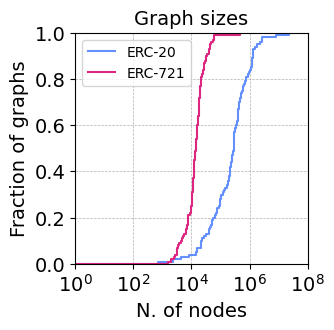

In [6]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Graph sizes')
ax.set_xlabel('N. of nodes')
ax.set_ylabel('Fraction of graphs')
ax.set_xscale('log')
sns.ecdfplot(df_f['num_nodes'], ax=ax, color='#648fff', label='ERC-20')
sns.ecdfplot(df_n['num_nodes'], ax=ax, color='#dc267f', label='ERC-721')
ax.grid(linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.legend()
ax.set_xlim(1, 1e8)
utils.set_font_size(ax, 14)
plt.savefig("figures/cumulative_nodes.pdf", format='pdf', bbox_inches='tight')
plt.show()

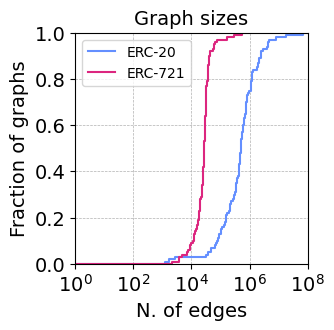

In [7]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Graph sizes')
ax.set_xlabel('N. of edges')
ax.set_ylabel('Fraction of graphs')
ax.set_xscale('log')
sns.ecdfplot(df_f['num_edges'], ax=ax, color='#648fff', label='ERC-20')
sns.ecdfplot(df_n['num_edges'], ax=ax, color='#dc267f', label='ERC-721')
ax.grid(linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.legend()
ax.set_xlim(1, 1e8)
utils.set_font_size(ax, 14)
plt.savefig("figures/cumulative_edges.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Graph features

Let $G$ be a token network and $G_{LCC}$ be the subgraph induced by the nodes and edges of its largest connected component.

We associate each $G$ with seven numerical features, namely:

1. Coverage, namely the percentage of nodes of $G$ included in $G_{LCC}$.
2. Relative diameter, which represents the ratio between the diameter of $G_{LCC}$ and the natural logarithm of the number of nodes.
3. Relative average shortest path length, which is computed as the average shortest path length of $G_{LCC}$ divided by the natural logarithm of the number of nodes.
4. Transitivity coincides with the global clustering coefficient of $G_{LCC}$, namely the ratio between the number of triangles and connected triples in the graph.
5. Density, as the ratio between the actual number of edges and the maximum possible number of edges in $G_{LCC}$.

We plot the distributions of the five selected features for the analyzed ERC-20 and ERC-721 token networks. 

All plots with a light blue (resp. red) color refer to fungible (resp. non-fungible) token networks.

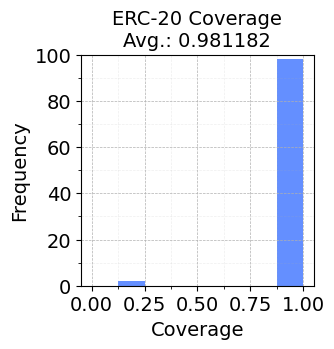

In [11]:
data = df_f['coverage'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Coverage\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Coverage')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0.0, 1.0+0.125, step=0.125), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 100)
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_feature_coverage_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

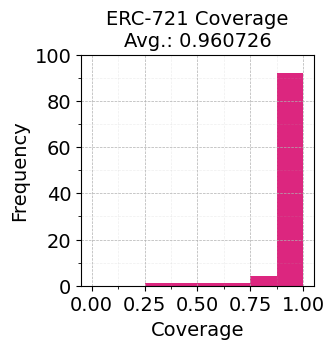

In [12]:
data = df_n['coverage'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Coverage\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Coverage')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0.0, 1.0+0.125, step=0.125), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 100)
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_feature_coverage_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

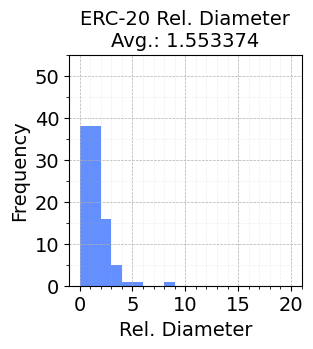

In [16]:
data = (df_f['diameter'].to_numpy()) / np.log(df_f['comp_nodes'].to_numpy())
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Rel. Diameter\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Rel. Diameter')
ax.set_ylabel('Frequency')
plt.hist(data, bins=np.arange(0, 20+1), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 55)
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_feature_diameter_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

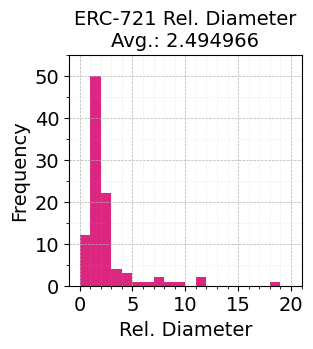

In [15]:
data = (df_n['diameter'].to_numpy()) / np.log(df_n['comp_nodes'].to_numpy())
#data = df_n['diameter'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Rel. Diameter\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Rel. Diameter')
ax.set_ylabel('Frequency')
plt.hist(data, bins=np.arange(0, 20+1), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 55)
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_feature_diameter_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

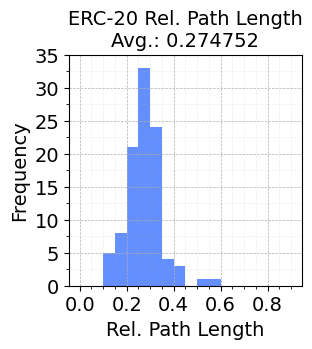

In [20]:
data = (df_f['est_apl'].to_numpy()) / np.log(df_f['comp_nodes'].to_numpy())
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Rel. Path Length\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Rel. Path Length')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0, 95, 5) / 100, color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 35)
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_feature_apl_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

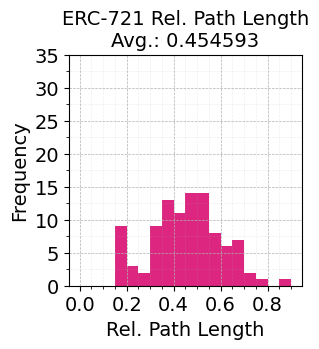

In [21]:
data = (df_n['est_apl'].to_numpy()) / np.log(df_n['comp_nodes'].to_numpy())
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Rel. Path Length\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Rel. Path Length')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0, 95, 5) / 100, color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 35)
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_feature_apl_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

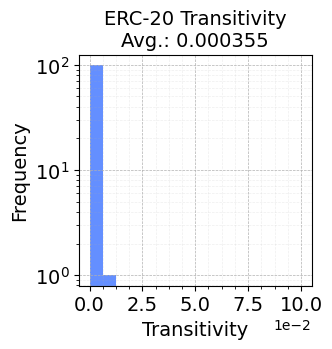

In [22]:
data = df_f['transitivity'].to_numpy()
hist_bins = np.arange(0, 0.1 + 0.00625, step=0.00625)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Transitivity\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Transitivity')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.hist(data, bins=hist_bins, color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,-2))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_feature_transitivity_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

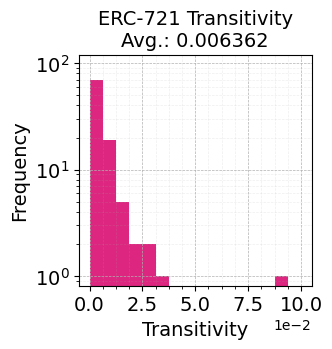

In [23]:
data = df_n['transitivity'].to_numpy()
hist_bins = np.arange(0, 0.1 + 0.00625, step=0.00625)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Transitivity\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Transitivity')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.hist(data, bins=hist_bins, color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,-2))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.set_ylim(top=120)
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_feature_transitivity_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

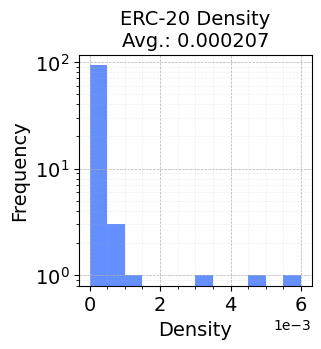

In [24]:
data = df_f['density'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Density\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Density')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.hist(data, bins=np.arange(0, 0.006 + 0.0005, step=0.0005), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3,-3))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_feature_density_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

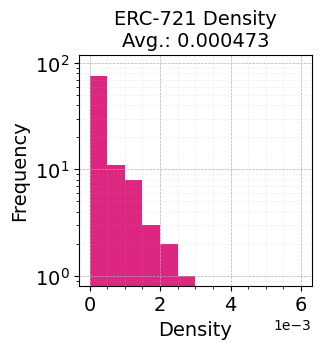

In [25]:
data = df_n['density'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Density\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Density')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.hist(data, bins=np.arange(0, 0.006 + 0.0005, step=0.0005), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3,-3))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.set_ylim(top=120)
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_feature_density_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Degree distribution analysis

In [3]:
deg_f = pl.read_csv('results/ft/ft_degree.tsv', separator='\t')
deg_n = pl.read_csv('results/nft/nft_degree.tsv', separator='\t')

In [20]:
print("ERC-20 accepted: ", len(deg_f.filter(pl.col("p_value").round(1) > 0.1)))
print("ERC-20 rejected: ", len(deg_f.filter(pl.col("p_value").round(1) <= 0.1)))
print("ERC-721 accepted: ", len(deg_n.filter(pl.col("p_value").round(1) > 0.1)))
print("ERC-721 rejected: ", len(deg_n.filter(pl.col("p_value").round(1) <= 0.1)))

ERC-20 accepted:  4
ERC-20 rejected:  96
ERC-721 accepted:  48
ERC-721 rejected:  52


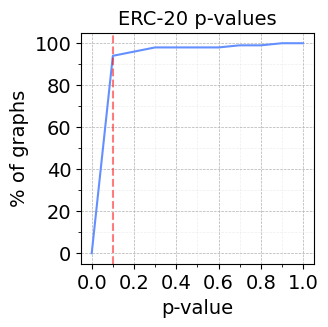

In [21]:
data = deg_f['p_value'].round(1)
step_hist = 0.1
step_plot = 0.2
hist, bins = np.histogram(data, bins = np.arange(0, 1+step_hist, step_hist))
hist = np.append([0], hist)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 p-values')
ax.set_xlabel('p-value')
ax.set_ylabel('% of graphs')
ax.plot(bins, np.cumsum(hist)*100/np.sum(hist), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks(np.arange(0, 1+step_plot, step_plot))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.axvline(0.1, color='red', alpha = 0.5, linestyle='--')
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_degree_p_cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()

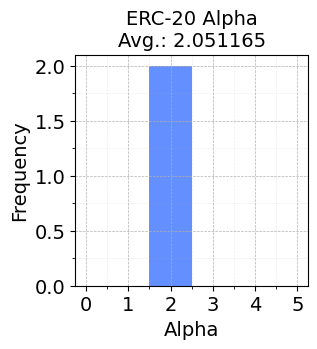

In [22]:
data = deg_f.filter(pl.col("p_value").round(1) > 0.1)['alpha'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Alpha\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Alpha')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0, 5+0.5, 0.5), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks(np.arange(0, 5+1, 1))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_degree_alpha_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

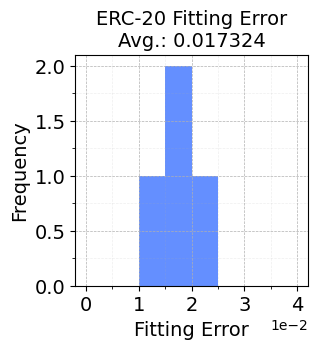

In [23]:
data = deg_f.filter(pl.col("p_value").round(1) > 0.1)['D'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Fitting Error\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Fitting Error')
ax.set_ylabel('Frequency')
ax.hist(data, bins=(np.arange(0, 4+0.5, 0.5) / 100), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks(np.arange(0, 4+1, 1) / 100)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,-2))
utils.set_font_size(ax, 14)
plt.savefig("figures/ft_degree_error_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

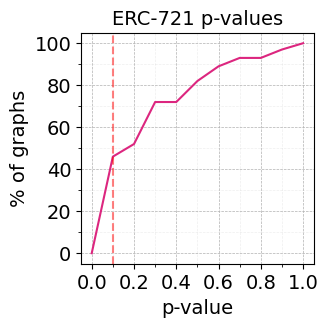

In [24]:
data = deg_n['p_value'].round(1)
step_hist = 0.1
step_plot = 0.2
hist, bins = np.histogram(data, bins = np.arange(0, 1+step_hist, step_hist))
hist = np.append([0], hist)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 p-values')
ax.set_xlabel('p-value')
ax.set_ylabel('% of graphs')
ax.plot(bins, np.cumsum(hist)*100/np.sum(hist), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks(np.arange(0, 1+step_plot, step_plot))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.axvline(0.1, color='red', alpha = 0.5, linestyle='--')
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_degree_p_cumul.pdf", format='pdf', bbox_inches='tight')
plt.show()

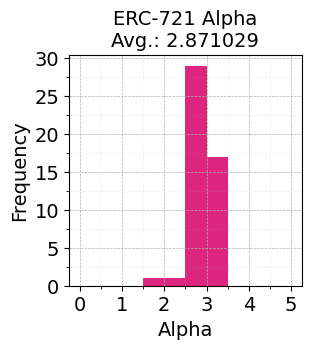

In [25]:
data = deg_n.filter(pl.col("p_value").round(1) > 0.1)['alpha'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Alpha\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Alpha')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0, 5+0.5, 0.5), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks(np.arange(0, 5+1, 1))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_degree_alpha_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

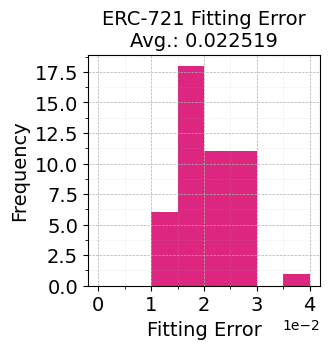

In [26]:
data = deg_n.filter(pl.col("p_value").round(1) > 0.1)['D'].to_numpy()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 Fitting Error\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Fitting Error')
ax.set_ylabel('Frequency')
ax.hist(data, bins=(np.arange(0, 4+0.5, 0.5) / 100), color='#dc267f')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks(np.arange(0, 4+1, 1) / 100)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,-2))
utils.set_font_size(ax, 14)
plt.savefig("figures/nft_degree_error_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

0.21843771739686435

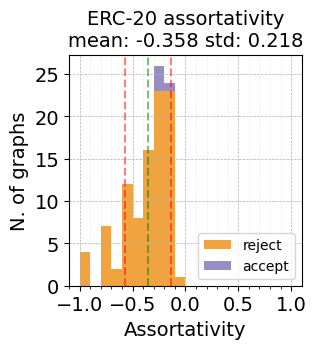

In [31]:
mean = deg_f['assortativity'].mean()
std = deg_f['assortativity'].std()
accepted = deg_f.filter(pl.col("p_value").round(1) > 0.1)['assortativity'].to_numpy()
rejected = deg_f.filter(pl.col("p_value").round(1) <= 0.1)['assortativity'].to_numpy()
step = 0.1

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 assortativity\nmean: {:.3f} std: {:.3f}'.format(mean, std))
ax.set_xlabel('Assortativity')
ax.set_ylabel('N. of graphs')
ax.hist([rejected, accepted], bins=np.arange(-1, 1+step, step=step), color=['#f1a340', '#998ec3'], label=['reject', 'accept'], stacked=True)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks(np.arange(-1, 1+0.5, step=0.5))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.axvline(mean, color='green', alpha = 0.5, linestyle='--')
ax.axvline(mean+std, color='red', alpha = 0.5, linestyle='--')
ax.axvline(mean-std, color='red', alpha = 0.5, linestyle='--')
ax.legend(loc='lower right')
utils.set_font_size(ax, 14)
#plt.savefig("figures/fig_6a_new.pdf", format='pdf', bbox_inches='tight')
plt.savefig("figures/ft_degree_assortativity.pdf", format='pdf', bbox_inches='tight')
plt.show()

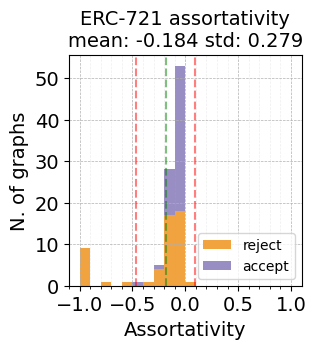

In [32]:
mean = deg_n['assortativity'].mean()
std = deg_n['assortativity'].std()
accepted = deg_n.filter(pl.col("p_value").round(1) > 0.1)['assortativity'].to_numpy()
rejected = deg_n.filter(pl.col("p_value").round(1) <= 0.1)['assortativity'].to_numpy()
step = 0.1

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-721 assortativity\nmean: {:.3f} std: {:.3f}'.format(mean, std))
ax.set_xlabel('Assortativity')
ax.set_ylabel('N. of graphs')
ax.hist([rejected, accepted], bins=np.arange(-1, 1+step, step=step), color=['#f1a340', '#998ec3'], label=['reject', 'accept'], stacked=True)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks(np.arange(-1, 1+0.5, step=0.5))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.axvline(mean, color='green', alpha = 0.5, linestyle='--')
ax.axvline(mean+std, color='red', alpha = 0.5, linestyle='--')
ax.axvline(mean-std, color='red', alpha = 0.5, linestyle='--')
ax.legend(loc='lower right')
utils.set_font_size(ax, 14)
#plt.savefig("figures/fig_6b_new.pdf", format='pdf', bbox_inches='tight')
plt.savefig("figures/nft_degree_assortativity.pdf", format='pdf', bbox_inches='tight')
plt.show()